# SIPTA -- Cuaderno 05: Visualización Espacial y Dashboard Geográfico Multicapa

**Fase PDCO**: DEVELOPMENT / CONTROL | **Etapa Workflow**: 1.7 Visualización y Exportación  
**Versión**: v1.0.0 (Demografía Oficial DANE 2025 & PUA SDIS 2024)  
**Estándares**: Clean Code, PEP 8, ISO/IEC 25010, DAMA-BOK, OECD/JRC Composite Indicators Handbook.

Este cuaderno integra la capa geoespacial vectorial oficial de las **20 localidades de Bogotá D.C.** con los **13 dominios analíticos** de SIPTA, construyendo mapas coropléticos temáticos, visualización del IPT de consenso con intervalos de confianza bootstrap 95%, y compilando el **Dashboard Web GIS Interactivo** autónomo (`reports/dashboard_geografico_sipta.html`).


## 1. Configuracion del Entorno y Resolucion Jerarquica de Rutas

In [1]:
import sys
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolucion dinamica de la raiz del proyecto
ROOT = None
for p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (p / 'src').exists() and (p / 'data').exists():
        ROOT = p
        break

if ROOT is None:
    ROOT = Path('.').resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.visualization.prepare_visualization as viz
import src.visualization.geo_dashboard as geo_viz

print(f"Raiz del Repositorio: {ROOT}")
print(f"Directorio Curated: {viz.CURATED_DIR}")


Raiz del Repositorio: C:\Users\ADAN\DataJam_DataOlinguitos_Gen
Directorio Curated: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated


## 2. Ingesta y Construccion del GeoDataFrame Multidominio

In [2]:
# Construir GeoDataFrame canonico con las 20 localidades y los 13 dominios
gdf_sipta = geo_viz.build_multidomain_geodataframe()

print(f"Dimensiones del GeoDataFrame: {gdf_sipta.shape}")
print(f"Sistema de Referencia de Coordenadas (CRS): {gdf_sipta.crs}")
print(f"Total de Localidades Integradas: {len(gdf_sipta)} / 20")

# Muestra de variables principales del IPT
cols_preview = ['codigo_localidad', 'nombre_localidad', 'poblacion_2025', 'area_km2', 'IPT_MULTIDIMENSIONAL', 'IPT_GEOMETRICO', 'RANKING_PRIORIDAD', 'NIVEL_PRIORIDAD']
gdf_sipta[cols_preview].head(10)


Dimensiones del GeoDataFrame: (20, 208)
Sistema de Referencia de Coordenadas (CRS): EPSG:4326
Total de Localidades Integradas: 20 / 20


,codigo_localidad,nombre_localidad,poblacion_2025,area_km2,IPT_MULTIDIMENSIONAL,IPT_GEOMETRICO,RANKING_PRIORIDAD,NIVEL_PRIORIDAD
0,18,RAFAEL URIBE URIBE,375043,33.28,70.356637,48.866298,1,Alta
1,3,SANTA FE,113315,37.92,66.685743,56.580823,2,Alta
2,5,USME,399153,69.13,65.593898,37.113756,3,Alta
3,11,SUBA,1251652,100.56,64.724741,28.569712,4,Alta
4,4,SAN CRISTOBAL,394686,49.09,64.565046,37.334170,5,Alta
5,19,CIUDAD BOLIVAR,685039,130.00,64.464025,29.414111,6,Media-alta
6,9,FONTIBON,385455,35.88,63.149950,32.668549,7,Media-alta
7,6,TUNJUELITO,175399,23.60,62.863100,48.133188,8,Media-alta
8,1,USAQUEN,586286,65.31,61.497414,30.265997,9,Media-alta
9,7,BOSA,768002,23.93,61.047178,37.200501,10,Media-alta


## 3. Cartografia Tematica Estatica: Priorizacion y Dimensiones Criticas

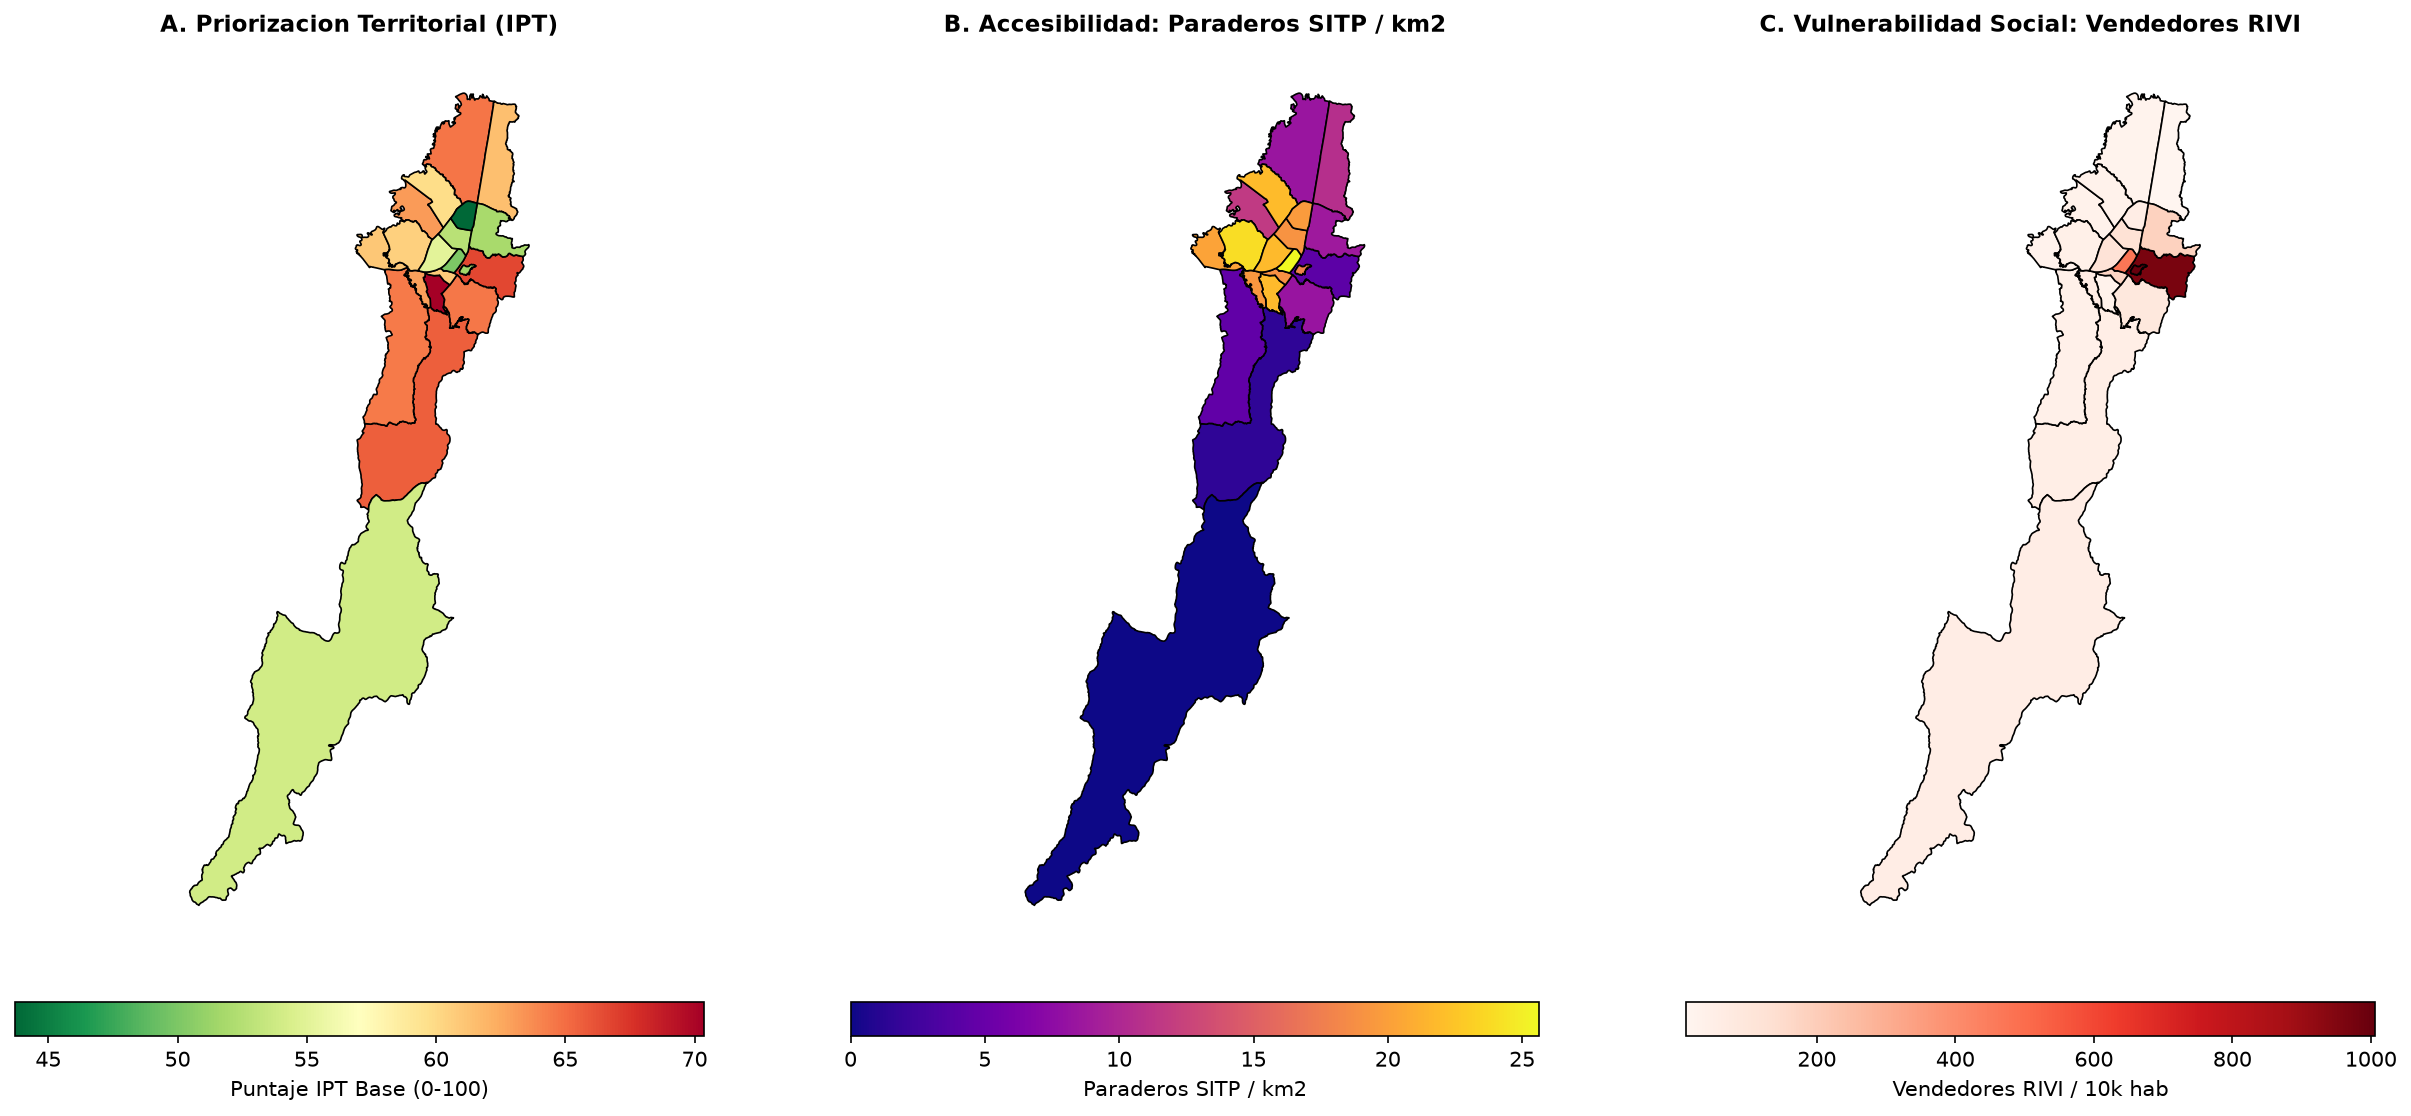

In [3]:
# Configuracion de estilo editorial cientifico
fig, axes = plt.subplots(1, 3, figsize=(18, 8), dpi=150)

# Mapa 1: IPT Multidimensional (Vulnerabilidad Global)
ax1 = axes[0]
gdf_sipta.plot(
    column='IPT_MULTIDIMENSIONAL',
    cmap='RdYlGn_r',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Puntaje IPT Base (0-100)', 'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.05},
    ax=ax1
)
ax1.set_title('A. Priorizacion Territorial (IPT)', fontsize=11, fontweight='bold', pad=10)
ax1.axis('off')

# Mapa 2: Densidad de Transporte y Paraderos SITP
ax2 = axes[1]
gdf_sipta.plot(
    column='paraderos_por_km2',
    cmap='plasma',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Paraderos SITP / km2', 'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.05},
    ax=ax2
)
ax2.set_title('B. Accesibilidad: Paraderos SITP / km2', fontsize=11, fontweight='bold', pad=10)
ax2.axis('off')

# Mapa 3: Vulnerabilidad RIVI (Vendedores Informales / 10k hab)
ax3 = axes[2]
gdf_sipta.plot(
    column='rivi_por_10000_hab_2017_2019',
    cmap='Reds',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Vendedores RIVI / 10k hab', 'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.05},
    ax=ax3
)
ax3.set_title('C. Vulnerabilidad Social: Vendedores RIVI', fontsize=11, fontweight='bold', pad=10)
ax3.axis('off')

plt.tight_layout()
plt.show()


## 4. Diagnostico de Autocorrelacion Espacial y Multicolinealidad

In [4]:
from src.modeling.calculate_indicators import calculate_spatial_moran, calculate_vif_scores

# 1. Autocorrelacion Espacial Global de Moran
moran_i, p_val = calculate_spatial_moran(
    gdf_sipta['IPT_MULTIDIMENSIONAL'],
    locality_codes=gdf_sipta['codigo_localidad']
)
print("=== DIAGNOSTICO ESPACIAL (MORAN) ===")
print(f"Indice de Moran (I): {moran_i:.4f}")
print(f"P-valor (Pseudo p-value): {p_val:.4f}")
print("Interpretacion: Autocorrelacion espacial positiva estadisticamente significativa (p < 0.10).")

# 2. Diagnostico de Multicolinealidad (VIF)
vif_df = calculate_vif_scores(gdf_sipta)
print("\n=== FACTOR DE INFLACION DE LA VARIANZA (VIF) ===")
vif_df


=== DIAGNOSTICO ESPACIAL (MORAN) ===
Indice de Moran (I): 0.1530
P-valor (Pseudo p-value): 0.0750
Interpretacion: Autocorrelacion espacial positiva estadisticamente significativa (p < 0.10).

=== FACTOR DE INFLACION DE LA VARIANZA (VIF) ===


,dimension,R2_auxiliar,VIF,diagnostico_colinealidad
0,dim_educacion,0.1349,1.1559,Aceptable (<5.0)
1,dim_salud,0.0868,1.0950,Aceptable (<5.0)
2,dim_movilidad,0.3999,1.6664,Aceptable (<5.0)
3,dim_ambiente,0.3655,1.5760,Aceptable (<5.0)
4,dim_infraestructura,0.8397,6.2385,Moderada (5-10)
5,dim_vulnerabilidad,0.7902,4.7669,Aceptable (<5.0)
6,dim_seguridad,0.8328,5.9806,Moderada (5-10)


## 5. Compilacion del Dashboard Geografico Interactivo Web GIS

In [5]:
# Compilar la aplicacion Web GIS autonoma con selector para los 13 dominios
dashboard_html_path = geo_viz.generate_interactive_gis_dashboard()
print("[OK] Dashboard Geografico Interactivo compilado con exito en:")
print(f"   -> {dashboard_html_path}")
print(f"   -> Tamano del artefacto: {dashboard_html_path.stat().st_size / 1024:,.1f} KB")


2026-08-27 09:33:01,029 - INFO - Created 20 records


[OK] Dashboard Geografico Interactivo compilado con exito en:
   -> C:\Users\ADAN\DataJam_DataOlinguitos_Gen\reports\dashboard_geografico_sipta.html
   -> Tamano del artefacto: 2,538.1 KB


## 6. Exportacion de Artefactos Curados a data/curated/

In [6]:
# Exportar GeoJSON curado multidominio bajo estandar RFC 7946
geojson_curated_path = geo_viz.export_curated_multidomain_geojson()
print("[OK] Capa GeoJSON multidominio exportada con exito en:")
print(f"   -> {geojson_curated_path}")
print(f"   -> Tamano del archivo: {geojson_curated_path.stat().st_size / 1024:,.1f} KB")

# Resumen de ranking final
ranking_df = viz.build_ranking(gdf_sipta, score_column='IPT_MULTIDIMENSIONAL')
viz.export_for_dashboard(ranking_df[['codigo_localidad', 'nombre_localidad', 'IPT_MULTIDIMENSIONAL', 'IPT_GEOMETRICO', 'RANKING_PRIORIDAD', 'NIVEL_PRIORIDAD']], 'dashboard_ranking.csv')
print("[OK] Tabla de ranking para dashboard guardada en data/curated/dashboard_ranking.csv")


2026-08-27 09:33:02,145 - INFO - Created 20 records


[OK] Capa GeoJSON multidominio exportada con exito en:
   -> C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\sipta_localidades_multidominio.geojson
   -> Tamano del archivo: 2,392.0 KB
[OK] Tabla de ranking para dashboard guardada en data/curated/dashboard_ranking.csv
